In [8]:
import numpy as np
import pandas as pd
import random

from sklearn.datasets import make_classification
     

In [9]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)
     

In [10]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-2.195587,-2.332324,0.075130,1.215492,2.715756,0
1,0.245410,0.055475,2.467248,1.000750,-0.765581,0
2,-2.323247,0.043804,-0.091691,0.656617,1.584612,0
3,-0.767028,1.152987,0.366254,2.169697,0.141728,1
4,1.918001,-0.411476,-0.039826,0.675264,-0.759986,1


In [11]:
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [12]:
# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [13]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [14]:
df1 = combined_sampling(df,0.5,0.5)

C:\Users\rdeva\AppData\Local\Temp\ipykernel_18532\3275485051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [15]:
df2 = combined_sampling(df,0.5,0.5)

C:\Users\rdeva\AppData\Local\Temp\ipykernel_18532\3275485051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [16]:
df3 = combined_sampling(df,0.5,0.5)

C:\Users\rdeva\AppData\Local\Temp\ipykernel_18532\3275485051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [17]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col4', 'col2', 'target'], dtype='object')
Index(['col4', 'col2', 'target'], dtype='object')
Index(['col3', 'col5', 'target'], dtype='object')


In [18]:

from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [20]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

DecisionTreeClassifier()

In [19]:
from sklearn.tree import plot_tree

[Text(0.4, 0.9166666666666666, 'x[1] <= -0.522\ngini = 0.487\nsamples = 50\nvalue = [21.0, 29.0]'),
 Text(0.13333333333333333, 0.75, 'x[1] <= -1.251\ngini = 0.111\nsamples = 17\nvalue = [16, 1]'),
 Text(0.26666666666666666, 0.8333333333333333, 'True  '),
 Text(0.06666666666666667, 0.5833333333333334, 'gini = 0.0\nsamples = 14\nvalue = [14, 0]'),
 Text(0.2, 0.5833333333333334, 'x[1] <= -0.963\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.13333333333333333, 0.4166666666666667, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.26666666666666666, 0.4166666666666667, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.6666666666666666, 0.75, 'x[0] <= 0.385\ngini = 0.257\nsamples = 33\nvalue = [5, 28]'),
 Text(0.5333333333333333, 0.8333333333333333, '  False'),
 Text(0.4666666666666667, 0.5833333333333334, 'x[1] <= 0.434\ngini = 0.426\nsamples = 13\nvalue = [4, 9]'),
 Text(0.4, 0.4166666666666667, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.5333333333333333, 0.4166666666666

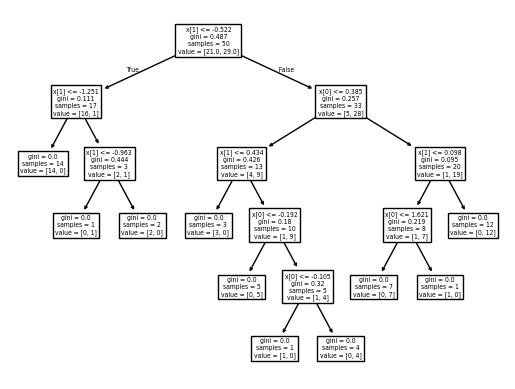

In [21]:
plot_tree(clf1)

[Text(0.39285714285714285, 0.9166666666666666, 'x[1] <= -0.522\ngini = 0.499\nsamples = 50\nvalue = [24, 26]'),
 Text(0.14285714285714285, 0.75, 'x[0] <= -0.718\ngini = 0.245\nsamples = 21\nvalue = [18, 3]'),
 Text(0.26785714285714285, 0.8333333333333333, 'True  '),
 Text(0.07142857142857142, 0.5833333333333334, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.21428571428571427, 0.5833333333333334, 'x[0] <= 1.831\ngini = 0.1\nsamples = 19\nvalue = [18, 1]'),
 Text(0.14285714285714285, 0.4166666666666667, 'gini = 0.0\nsamples = 16\nvalue = [16, 0]'),
 Text(0.2857142857142857, 0.4166666666666667, 'x[0] <= 2.405\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.21428571428571427, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.35714285714285715, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.6428571428571429, 0.75, 'x[1] <= 0.066\ngini = 0.328\nsamples = 29\nvalue = [6, 23]'),
 Text(0.5178571428571429, 0.8333333333333333, '  False'),
 Text(0.5, 0.58333333333333

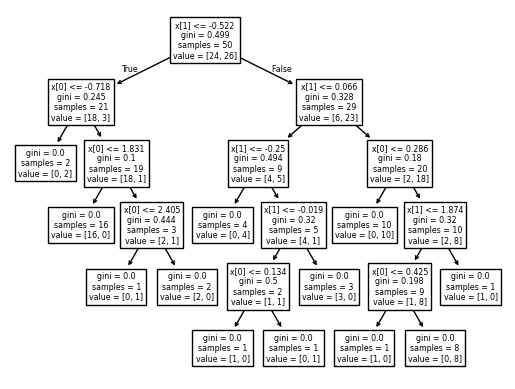

In [22]:
plot_tree(clf2)

[Text(0.6111111111111112, 0.9375, 'x[0] <= 1.621\ngini = 0.487\nsamples = 50\nvalue = [29.0, 21.0]'),
 Text(0.3333333333333333, 0.8125, 'x[1] <= 1.153\ngini = 0.497\nsamples = 26\nvalue = [12, 14]'),
 Text(0.4722222222222222, 0.875, 'True  '),
 Text(0.16666666666666666, 0.6875, 'x[1] <= -1.245\ngini = 0.355\nsamples = 13\nvalue = [3, 10]'),
 Text(0.1111111111111111, 0.5625, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.2222222222222222, 0.5625, 'x[1] <= 0.394\ngini = 0.278\nsamples = 12\nvalue = [2, 10]'),
 Text(0.16666666666666666, 0.4375, 'x[1] <= 0.25\ngini = 0.408\nsamples = 7\nvalue = [2, 5]'),
 Text(0.1111111111111111, 0.3125, 'x[0] <= 1.216\ngini = 0.278\nsamples = 6\nvalue = [1, 5]'),
 Text(0.05555555555555555, 0.1875, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.16666666666666666, 0.1875, 'x[0] <= 1.439\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.1111111111111111, 0.0625, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.2222222222222222, 0.0625, 'gini =

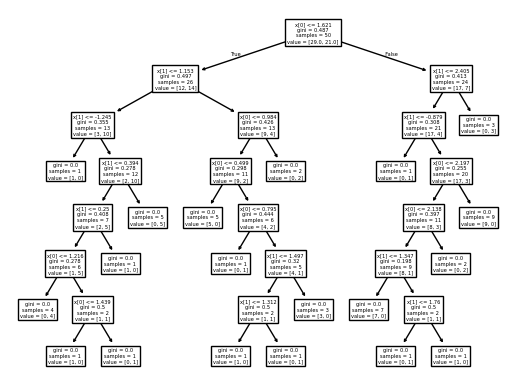

In [23]:
plot_tree(clf3)

In [24]:
clf1.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

c:\Users\rdeva\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [25]:
clf2.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

c:\Users\rdeva\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [26]:
clf3.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

c:\Users\rdeva\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])